In [5]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from ipywidgets import interact
from scipy.ndimage import gaussian_filter

In [6]:
# =========================
# GEOMETRIA
# =========================
Lx = 0.05        # [m] lunghezza orizzontale, periodica
Lz = 0.0013      # [m] altezza verticale

# =========================
# ACQUA (~300 K)
# =========================
rho0 = 997.0     # [kg/m^3] densità di riferimento
nu = 1.0e-6      # [m^2/s] viscosità cinematica
kappa = 1.4e-7   # [m^2/s] diffusività termica
alpha = 2.1e-4   # [1/K] coefficiente di espansione termica
g = 9.81         # [m/s^2] gravità

# =========================
# TEMPERATURE
# =========================
#T_bottom = 310.0 # [K] fondo caldo
#T_top = 300.0    # [K] tetto freddo
T_bottom = 350.0 # [K] fondo caldo
T_top = 250.0    # [K] tetto freddo
T_ref = 300.0    # [K] temperatura di riferimento

# =========================
# NUMERICA
# =========================
Nx = 128         # [-] modi/punti in x
Nz = 64          # [-] modi/punti in z
dealias = 3/2    # [-]
#dt_sim = 2e-4   # [s] timestep iniziale
#dt_sim = 2e-2   # [s] timestep iniziale
#t_end = 50.0    # [s] tempo finale iniziale

dt_sim = 1e-3    # [s] passo temporale (fatto)
#dt_sim = 5e-4
dt_sim = 2e-2
#dt_sim = 1e-3

t_end = 50.0     # [s] tempo finale
save_every = 20  # [-] salva un frame ogni N step

In [7]:
DeltaT = T_bottom - T_top                      # [K]
Ra = g * alpha * DeltaT * Lz**3 / (nu*kappa)   # [-]
Pr = nu / kappa                                # [-]

print(f"Rayleigh = {Ra:.3e}")
print(f"Prandtl  = {Pr:.3f}")

Rayleigh = 3.233e+03
Prandtl  = 7.143


In [8]:
coords = d3.CartesianCoordinates('x', 'z')
dist = d3.Distributor(coords, dtype=np.float64)

xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

x, z = dist.local_grids(xbasis, zbasis)
ex, ez = coords.unit_vector_fields(dist)

In [9]:
# Campi principali
p = dist.Field(name='p', bases=(xbasis, zbasis))                      # [Pa]
T = dist.Field(name='T', bases=(xbasis, zbasis))                      # [K]
u = dist.VectorField(coords, name='u', bases=(xbasis, zbasis))        # [m/s]

# Tau fields
tau_p  = dist.Field(name='tau_p')                                     # [-] rende ben posto il vincolo di incomprimibilità
tau_T1 = dist.Field(name='tau_T1', bases=xbasis)                      # [K/m] corregge il gradiente
tau_T2 = dist.Field(name='tau_T2', bases=xbasis)                      # [K/m^2] corregge il Laplaciano/equazione completa
tau_u1 = dist.VectorField(coords, name='tau_u1', bases=xbasis)        # [1/s] per la velocità, entra nel gradient
tau_u2 = dist.VectorField(coords, name='tau_u2', bases=xbasis)        # [m/s^2] per la velocità, entra nell'eq. finale

In [10]:
lift_basis = zbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)

grad_u = d3.grad(u) + ez * lift(tau_u1)
grad_T = d3.grad(T) + ez * lift(tau_T1)

In [11]:
problem = d3.IVP([p, T, u, tau_p, tau_T1, tau_T2, tau_u1, tau_u2], namespace=locals())

# Incompressibilità
problem.add_equation("trace(grad_u) + tau_p = 0")

# Temperatura
problem.add_equation("dt(T) - kappa*div(grad_T) + lift(tau_T2) = - u@grad(T)")

# Quantità di moto
problem.add_equation("dt(u) - nu*div(grad_u) + grad(p)/rho0 + lift(tau_u2) = - u@grad(u) + g*alpha*(T - T_ref)*ez")

# Boundary conditions in z
problem.add_equation("T(z=0) = T_bottom")
problem.add_equation("T(z=Lz) = T_top")
problem.add_equation("u(z=0) = 0")
problem.add_equation("u(z=Lz) = 0")

# Gauge pressione
problem.add_equation("integ(p) = 0")

{'eqn': Integrate(Integrate(<Field 5146247760>)),
 'LHS': Integrate(Integrate(<Field 5146247760>)),
 'RHS': 0,
 'condition': 'True',
 'tensorsig': (),
 'dtype': numpy.float64,
 'valid_modes': array([[ True]]),
 'M': 0,
 'L': Integrate(Integrate(<Field 5146247760>)),
 'F': <Field 5146348432>,
 'domain': <dedalus.core.domain.Domain at 0x132c72690>,
 'matrix_dependence': array([ True,  True]),
 'matrix_coupling': array([False,  True])}

In [12]:
solver = problem.build_solver(d3.RK222) 
solver.stop_sim_time = t_end

print("Solver costruito correttamente")

2026-05-28 10:55:39,498 subsystems 0/1 INFO :: Building subproblem matrices 1/64 (~2%) Elapsed: 0s, Remaining: 4s, Rate: 1.5e+01/s
2026-05-28 10:55:39,632 subsystems 0/1 INFO :: Building subproblem matrices 7/64 (~11%) Elapsed: 0s, Remaining: 2s, Rate: 3.5e+01/s
2026-05-28 10:55:39,786 subsystems 0/1 INFO :: Building subproblem matrices 14/64 (~22%) Elapsed: 0s, Remaining: 1s, Rate: 3.9e+01/s
2026-05-28 10:55:39,940 subsystems 0/1 INFO :: Building subproblem matrices 21/64 (~33%) Elapsed: 1s, Remaining: 1s, Rate: 4.1e+01/s
2026-05-28 10:55:40,095 subsystems 0/1 INFO :: Building subproblem matrices 28/64 (~44%) Elapsed: 1s, Remaining: 1s, Rate: 4.2e+01/s
2026-05-28 10:55:40,250 subsystems 0/1 INFO :: Building subproblem matrices 35/64 (~55%) Elapsed: 1s, Remaining: 1s, Rate: 4.3e+01/s
2026-05-28 10:55:40,404 subsystems 0/1 INFO :: Building subproblem matrices 42/64 (~66%) Elapsed: 1s, Remaining: 1s, Rate: 4.3e+01/s
2026-05-28 10:55:40,559 subsystems 0/1 INFO :: Building subproblem matri

In [13]:
# Profilo conduttivo lineare
# Profilo conduttivo (lineare)

T['g'] = T_bottom + (T_top - T_bottom) * (z / Lz)

# =========================
# Perturbazione randomica
# =========================



noise = dist.Field(name='noise', bases=(xbasis, zbasis))

# riempi con rumore gaussiano
noise.fill_random('g', seed=42, distribution='normal', scale=1.0)

# scala la perturbazione: 10^-3 K
pert = 1e-3 * noise['g']

# la facciamo andare a zero sui bordi (importantissimo!)
pert *= (z * (Lz - z))

# smoothing leggero (opzionale)

pert = gaussian_filter(pert, sigma=1)

# aggiungi alla temperatura
T['g'] += pert

# =========================
# Velocità iniziale nulla
# =========================

u['g'][0] = 0.0
u['g'][1] = 0.0

print("max perturbazione =", np.max(np.abs(pert)))

max perturbazione = 4.177882671681601e-10


In [14]:
#while solver.proceed:
#    solver.step(dt_sim)
#    if solver.iteration % save_every == 0:
#        times.append(solver.sim_time)
#        T_all.append(T['g'].copy())
#        Ux_all.append(u['g'][0].copy())
#        Uz_all.append(u['g'][1].copy())
#print("Simulazione finita")
#print("Numero frame salvati:", len(T_all))
times = []
T_all = []
Ux_all = []
Uz_all = []

umax_all = []
wmax_all = []
ke_all = []
cfl_all = []

dx = Lx / Nx        # [m]
dz = Lz / Nz        # [m]

while solver.proceed:
    solver.step(dt_sim)

    Ux_now = u['g'][0]
    Uz_now = u['g'][1]

    umax = np.max(np.abs(Ux_now))       # [m/s]
    wmax = np.max(np.abs(Uz_now))       # [m/s]
    ke = np.mean(Ux_now**2 + Uz_now**2) # [m^2/s^2]

    cfl = dt_sim * (umax/dx + wmax/dz)

    if solver.iteration % save_every == 0:
        times.append(solver.sim_time)
        T_all.append(T['g'].copy())
        Ux_all.append(Ux_now.copy())
        Uz_all.append(Uz_now.copy())

        umax_all.append(umax)
        wmax_all.append(wmax)
        ke_all.append(ke)
        cfl_all.append(cfl)

        print(
            f"iter={solver.iteration:6d}, "
            f"t={solver.sim_time:9.4f} s, "
            f"umax={umax:.3e}, "
            f"wmax={wmax:.3e}, "
            f"CFL={cfl:.3e}"
        )

print("Simulazione finita")
print("Numero frame salvati:", len(T_all))



iter=    20, t=   0.4000 s, umax=3.896e-15, wmax=4.120e-15, CFL=4.256e-12
iter=    40, t=   0.8000 s, umax=5.553e-15, wmax=6.098e-15, CFL=6.289e-12
iter=    60, t=   1.2000 s, umax=8.461e-15, wmax=9.301e-15, CFL=9.591e-12
iter=    80, t=   1.6000 s, umax=1.394e-14, wmax=1.489e-14, CFL=1.537e-11
iter=   100, t=   2.0000 s, umax=2.306e-14, wmax=2.502e-14, CFL=2.581e-11
iter=   120, t=   2.4000 s, umax=3.832e-14, wmax=4.213e-14, CFL=4.344e-11
iter=   140, t=   2.8000 s, umax=6.397e-14, wmax=7.109e-14, CFL=7.327e-11
iter=   160, t=   3.2000 s, umax=1.072e-13, wmax=1.202e-13, CFL=1.238e-10
iter=   180, t=   3.6000 s, umax=1.802e-13, wmax=2.034e-13, CFL=2.095e-10
iter=   200, t=   4.0000 s, umax=3.038e-13, wmax=3.448e-13, CFL=3.551e-10
iter=   220, t=   4.4000 s, umax=5.132e-13, wmax=5.850e-13, CFL=6.023e-10
iter=   240, t=   4.8000 s, umax=8.683e-13, wmax=9.934e-13, CFL=1.023e-09
iter=   260, t=   5.2000 s, umax=1.477e-12, wmax=1.688e-12, CFL=1.738e-09
iter=   280, t=   5.6000 s, umax=2.528

In [15]:
times = np.array(times)
T_all = np.array(T_all)
Ux_all = np.array(Ux_all)
Uz_all = np.array(Uz_all)

umax_all = np.array(umax_all)
wmax_all = np.array(wmax_all)
ke_all = np.array(ke_all)
cfl_all = np.array(cfl_all)

#X = x
#Z = z

x_plot, z_plot = dist.local_grids(xbasis, zbasis, scales=dealias)

X, Z = np.meshgrid(x_plot[:, 0], z_plot[0, :], indexing='ij')

print("X.shape =", X.shape)
print("Z.shape =", Z.shape)
print("T_all.shape =", T_all.shape)

print("shape X =", X.shape)
print("shape Z =", Z.shape)
print("shape T_all =", T_all.shape)
print("Shape T_all  =", T_all.shape)
print("Shape Ux_all =", Ux_all.shape)
print("Shape Uz_all =", Uz_all.shape)

X.shape = (192, 96)
Z.shape = (192, 96)
T_all.shape = (125, 192, 96)
shape X = (192, 96)
shape Z = (192, 96)
shape T_all = (125, 192, 96)
Shape T_all  = (125, 192, 96)
Shape Ux_all = (125, 192, 96)
Shape Uz_all = (125, 192, 96)


Tempo selezionato = 40.000000000000654 s
Modo dominante n = 23
Numero d'onda adimensionale a = k Lz = 3.757344813693392
Valore teorico critico no-slip ~ 3.117


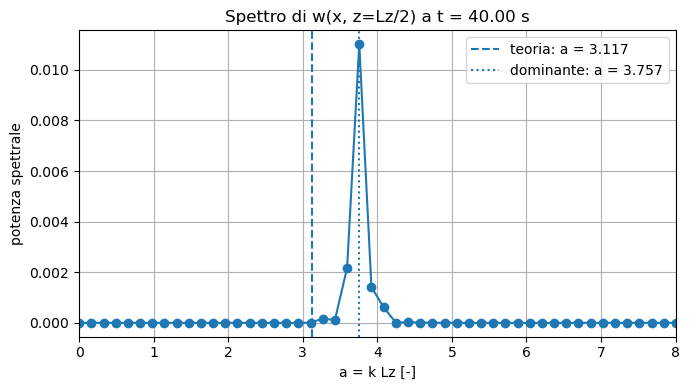

In [16]:
t_target = 40.0  # [s]

# indice del frame più vicino a t = 40 s
i_t = np.argmin(np.abs(times - t_target))

print("Tempo selezionato =", times[i_t], "s")

Uz_frame = Uz_all[i_t]

# prendo il profilo verticale a metà altezza
j_mid = np.argmin(np.abs(Z[0, :] - Lz/2))

w_mid = Uz_frame[:, j_mid]
w_mid = w_mid - np.mean(w_mid)

# FFT lungo x
w_hat = np.fft.rfft(w_mid)
power = np.abs(w_hat)**2

modes = np.arange(len(power))
k = 2*np.pi*modes/Lx      # [rad/m]
a = k*Lz                  # [-]

power[0] = 0

idx = np.argmax(power)

print("Modo dominante n =", modes[idx])
print("Numero d'onda adimensionale a = k Lz =", a[idx])
print("Valore teorico critico no-slip ~ 3.117")

plt.figure(figsize=(7,4))
plt.plot(a, power, 'o-')
plt.axvline(3.117, linestyle='--', label='teoria: a = 3.117')
plt.axvline(a[idx], linestyle=':', label=f'dominante: a = {a[idx]:.3f}')
plt.xlim(0, 8)
plt.xlabel('a = k Lz [-]')
plt.ylabel('potenza spettrale')
plt.title(f'Spettro di w(x, z=Lz/2) a t = {times[i_t]:.2f} s')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

interactive(children=(IntSlider(value=0, description='n', max=124), Output()), _dom_classes=('widget-interact'…

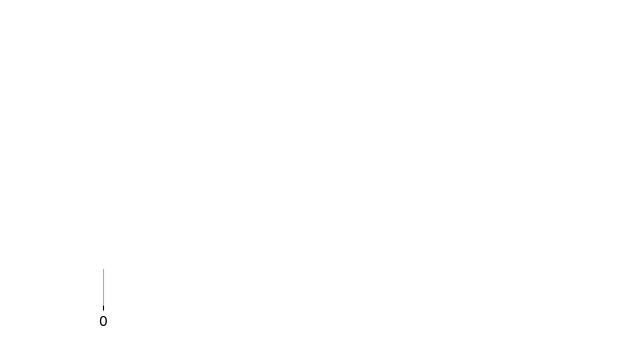

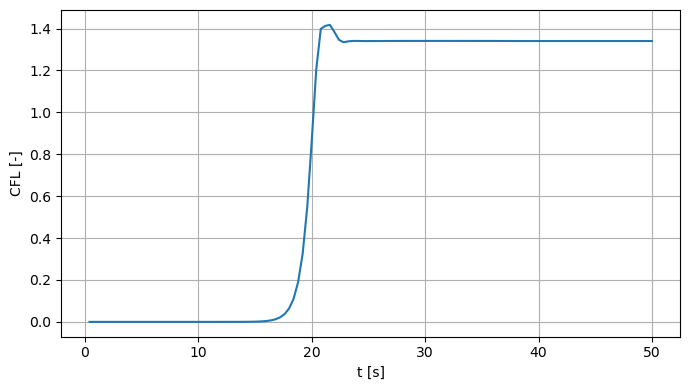

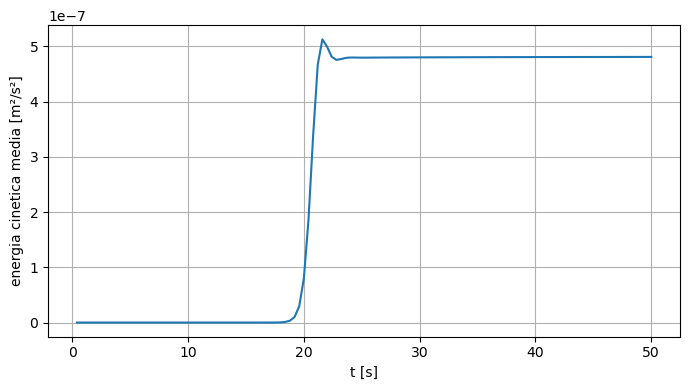

In [17]:
def plot_frame(n=0):
    Tn = T_all[n]
    Ux = Ux_all[n]
    Uz = Uz_all[n]
    speed = np.sqrt(Ux**2 + Uz**2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    cf = ax[0].contourf(X, Z, Tn, levels=40, cmap='coolwarm')
    plt.colorbar(cf, ax=ax[0], label='Temperatura [K]')
    ax[0].set_xlabel('x [m]')
    ax[0].set_ylabel('z [m]')
    ax[0].set_title(f'Temperatura, t = {times[n]:.4f} s')

    c2 = ax[1].contourf(X, Z, speed, levels=30, cmap='Greys')

    skipx = 6
    skipz = 4
    ax[1].quiver(
        X[::skipx, ::skipz],
        Z[::skipx, ::skipz],
        Ux[::skipx, ::skipz],
        Uz[::skipx, ::skipz],
        color='black',
        pivot='mid'
    )

    plt.colorbar(c2, ax=ax[1], label='|u| [m/s]')
    ax[1].set_xlabel('x [m]')
    ax[1].set_ylabel('z [m]')
    ax[1].set_title(f'Campo di velocità, t = {times[n]:.4f} s')

    plt.tight_layout()
    plt.show()

interact(plot_frame, n=(0, len(times)-1, 1));

plt.figure(figsize=(7,4))
plt.plot(times, umax_all, label='max |u_x|')
plt.plot(times, wmax_all, label='max |u_z|')
plt.xlabel('t [s]')
plt.ylabel('velocità massima [m/s]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(times, cfl_all)
plt.xlabel('t [s]')
plt.ylabel('CFL [-]')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(times, ke_all)
plt.xlabel('t [s]')
plt.ylabel('energia cinetica media [m²/s²]')
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
import sys
print(sys.executable)

/Users/alicevullo/miniforge3/envs/tesi/bin/python
